# Problema 3: Ecualización de Canal de Comunicación

**Estudiante:** Kent Lin Chan (20202132)

**Curso:** IEE352 — Procesamiento Digital de Señales (2026-1)

**Python:** 3.14.2

---

En este problema hay que recuperar un mensaje que se transmitió por un canal con interferencia entre símbolos (ISI). La idea es armar un ecualizador adaptativo que limpie la señal recibida.

El mensaje se codificó en ASCII de 8 bits, se pasó a QPSK y se mandó por un canal que mete interferencia entre símbolos. Del otro lado recibimos una señal `y` toda distorsionada.

El archivo `data_comm.npz` trae:

- `y`: la señal compleja recibida, 3744 símbolos QPSK en total.
- `training`: los primeros 200 caracteres transmitidos (800 símbolos QPSK), que usamos como referencia para entrenar el ecualizador. El resto (2944 símbolos, 736 caracteres) es el mensaje que hay que recuperar.

La meta: diseñar un ecualizador adaptativo (lineal o con decisión retroalimentada) que reduzca la ISI y deje leer el mensaje completo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo global de figuras
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110

# --- Carga de datos ---
data = np.load('data_comm.npz')
y = data['y']                      # Señal recibida (compleja)
training = data['training']        # 200 caracteres de entrenamiento

print(f'Longitud de y: {len(y)} símbolos QPSK')
print(f'Training: {len(training)} caracteres = {len(training)*4} símbolos QPSK')
print(f'Mensaje a recuperar: {(len(y) - len(training)*4)} símbolos = {(len(y) - len(training)*4)//4} caracteres')
print(f'\nPrimeros 20 caracteres de training: {"".join(training[:20])}')
print(f'\nEstadísticas de y (primeros 200 símbolos):')
print(f'  |y| media: {np.mean(np.abs(y[:200])):.3f}, std: {np.std(np.abs(y[:200])):.3f}')
print(f'  Re(y) std: {np.std(y[:200].real):.3f}, Im(y) std: {np.std(y[:200].imag):.3f}')


Longitud de y: 3744 símbolos QPSK
Training: 200 caracteres = 800 símbolos QPSK
Mensaje a recuperar: 2944 símbolos = 736 caracteres

Primeros 20 caracteres de training: KCxc-Rz_snbJS/O ;7{|

Estadísticas de y (primeros 200 símbolos):
  |y| media: 3.250, std: 1.293
  Re(y) std: 2.511, Im(y) std: 2.381


## 1. Carga de datos y codificación QPSK

Empezamos cargando los datos y revisando las estadísticas básicas. Cada carácter ASCII son 8 bits y cada símbolo QPSK carga 2 bits, así que cada carácter son 4 símbolos QPSK.


In [2]:
def ascii_to_bits(chars):
    """Convierte una secuencia de caracteres a bits (MSB primero por carácter)."""
    bits = []
    for c in chars:
        v = ord(c)
        for i in range(7, -1, -1):  # MSB primero
            bits.append((v >> i) & 1)
    return np.array(bits, dtype=np.int8)

def bits_to_ascii(bits):
    """Convierte una secuencia de bits (múltiplos de 8) a string ASCII."""
    n_chars = len(bits) // 8
    out = []
    for i in range(n_chars):
        v = 0
        for j in range(8):
            v = (v << 1) | int(bits[i*8 + j])
        out.append(chr(v))
    return ''.join(out)

def ascii_to_qpsk(chars):
    """Texto -> símbolos QPSK según x[n] = (-1)^a_2n + j*(-1)^a_2n+1."""
    bits = ascii_to_bits(chars)
    N = len(bits) // 2
    a = bits[:2*N]
    x = ((-1) ** a[0::2]) + 1j * ((-1) ** a[1::2])
    return x, a

def qpsk_decide(y_eq):
    """Decisión hard por signo: parte real -> a_2n, parte imag -> a_2n+1."""
    a0_hat = 0 if y_eq.real > 0 else 1
    a1_hat = 0 if y_eq.imag > 0 else 1
    return a0_hat, a1_hat

def qpsk_symbol(a0, a1):
    """Símbolo QPSK a partir de dos bits de decisión."""
    return (1 - 2*a0) + 1j * (1 - 2*a1)

# --- Construir la secuencia de referencia (training) ---
x_train, bits_train = ascii_to_qpsk(training)
N_TRAIN = len(x_train)   # 800 símbolos

print(f'Secuencia training: {N_TRAIN} símbolos QPSK')
print(f'Primeros 6 símbolos training: {x_train[:6]}')

# Verificación: decodificar los primeros 8 símbolos (2 caracteres)
primeros_8_bits = []
for s in x_train[:8]:
    primeros_8_bits.append(0 if s.real > 0 else 1)
    primeros_8_bits.append(0 if s.imag > 0 else 1)
print(f'Bits decodificados de los primeros 8 símbolos: {primeros_8_bits}')
print(f'Primeros 2 chars decodificados: {bits_to_ascii(primeros_8_bits)!r}')
print(f'Primeros 2 chars reales:       {"".join(training[:2])!r}')


Secuencia training: 800 símbolos QPSK
Primeros 6 símbolos training: [ 1.-1.j  1.+1.j -1.+1.j -1.-1.j  1.-1.j  1.+1.j]
Bits decodificados de los primeros 8 símbolos: [0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1]
Primeros 2 chars decodificados: 'KC'
Primeros 2 chars reales:       'KC'


## 2. Funciones de modulación y decodificación

Acá van las funciones para convertir texto a bits, bits a símbolos QPSK y al revés. Uso la convención del enunciado: MSB primero por carácter, y el mapeo es `(-1)^a + j*(-1)^b`.


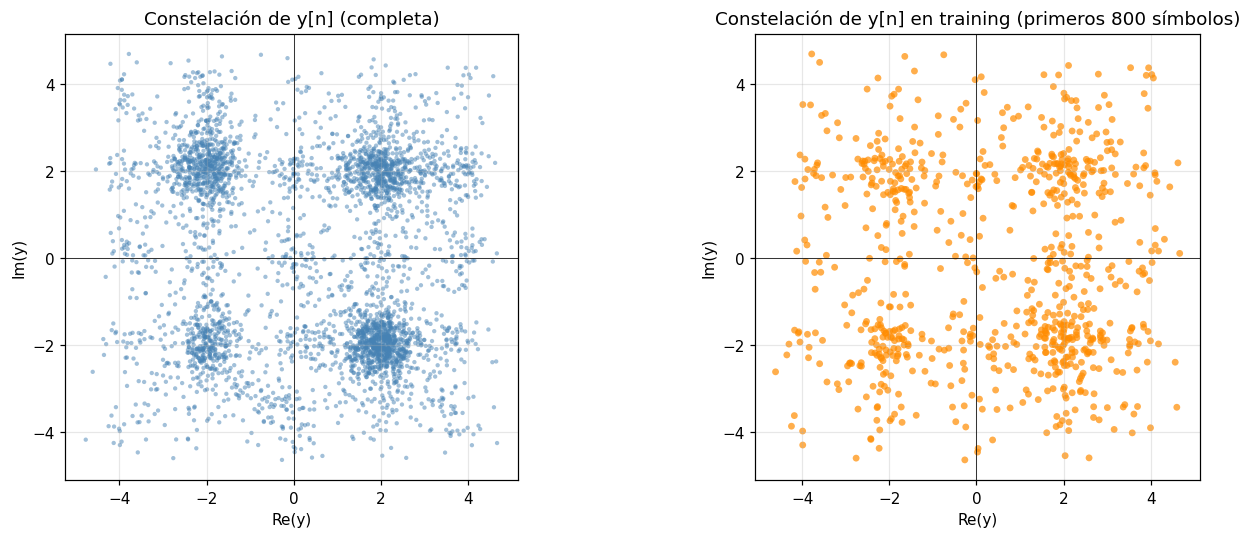

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Constelación completa
axes[0].scatter(y.real, y.imag, s=8, alpha=0.5, c='steelblue', edgecolor='none')
axes[0].set_xlabel('Re(y)'); axes[0].set_ylabel('Im(y)')
axes[0].set_title('Constelación de y[n] (completa)')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

# Zoom en primeros 200 símbolos (training)
axes[1].scatter(y[:N_TRAIN].real, y[:N_TRAIN].imag, s=20, alpha=0.7, c='darkorange', edgecolor='none')
axes[1].set_xlabel('Re(y)'); axes[1].set_ylabel('Im(y)')
axes[1].set_title(f'Constelación de y[n] en training (primeros {N_TRAIN} símbolos)')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()


## 3. Constelación de la señal recibida

Graficamos la señal `y` recibida. Como el canal mete interferencia, los puntos se ven dispersos en lugar de quedar en los cuatro puntitos limpios del QPSK ideal.


## 4. Modelo del ecualizador LMS lineal

El ecualizador es un filtro FIR con coeficientes complejos que toma muestras de la señal recibida y produce una estimación del símbolo original. La idea es ajustar los coeficientes para que la salida se parezca al símbolo transmitido.

Tiene dos modos de operación:

1. **Entrenamiento supervisado**: usamos los símbolos de training como referencia para calcular el error.
2. **Modo decision-directed (DD)**: cuando se acaba el training, el ecualizador sigue actualizándose pero usa sus propias decisiones como referencia. Esto es clave cuando el canal cambia con el tiempo, porque le permite seguir esos cambios sin necesidad de símbolos conocidos.

En DD se usa un paso más chico que en training para evitar que un error de decisión se propague y arruine la adaptación.


## 5. Implementación del ecualizador LMS lineal

Acá va el código de las dos versiones del LMS: el lineal puro (solo usa la señal recibida) y el DFE (le suma un filtro que usa las decisiones pasadas para cancelar interferencia de símbolos anteriores).

Ambas funciones devuelven los bits decididos símbolo por símbolo, así después podemos medir BER y reconstruir el mensaje.


In [ ]:
def lms_equalizer(y_full, x_ref, L, mu_train, mu_dd, D=0, train_len=None,
                  w_init=None):
    """
    Ecualizador LMS lineal (forward) con modo decision-directed.
    
    out[n] = w^H [y[n-D], y[n-D-1], ..., y[n-D-L+1]]
    Retorna: (w, a0, a1, se_hist) donde a0, a1 son los bits decididos por
    el equalizer para cada n (alineados con n = D, D+1, ...).
    """
    if train_len is None:
        train_len = len(x_ref)
    w = np.zeros(L, dtype=complex) if w_init is None else w_init.copy()
    N = len(y_full)
    a0, a1 = [], []
    se_hist = []
    for n in range(D, N):
        x_vec = np.array([y_full[n - D - k] for k in range(L)], dtype=complex)
        y_eq = np.vdot(w, x_vec)
        ai0, ai1 = qpsk_decide(y_eq)
        a0.append(ai0); a1.append(ai1)
        if n < train_len:
            e = x_ref[n] - y_eq
            w = w + mu_train * np.conj(e) * x_vec
        else:
            d_hat = qpsk_symbol(ai0, ai1)
            e = d_hat - y_eq
            w = w + mu_dd * np.conj(e) * x_vec
        se_hist.append(abs(e)**2)
    return w, np.array(a0), np.array(a1), np.array(se_hist)


def lms_dfe_equalizer(y_full, x_ref, L_f, L_b, mu_train, mu_dd, D=0,
                     train_len=None, w_f_init=None, w_b_init=None):
    """
    Ecualizador LMS con Decision Feedback (DFE).
    out[n] = w_f^H [y[n-D], ..., y[n-D-L_f+1]] - w_b^H [d_hat[n-1], d_hat[n-2], ...]
    Empieza a producir decisiones en n = max(D + L_f, L_b).
    """
    if train_len is None:
        train_len = len(x_ref)
    w_f = np.zeros(L_f, dtype=complex) if w_f_init is None else w_f_init.copy()
    w_b = np.zeros(L_b, dtype=complex) if w_b_init is None else w_b_init.copy()
    N = len(y_full)
    a0, a1 = [], []
    se_hist = []
    b_hist = np.zeros(L_b, dtype=complex)  # decisiones pasadas
    start = max(D + L_f, L_b)
    for n in range(start, N):
        x_vec_f = np.array([y_full[n - D - k] for k in range(L_f)], dtype=complex)
        y_f = np.vdot(w_f, x_vec_f)
        y_b = np.vdot(w_b, b_hist)
        y_eq = y_f - y_b
        ai0, ai1 = qpsk_decide(y_eq)
        a0.append(ai0); a1.append(ai1)
        if n < train_len:
            e = x_ref[n] - y_eq
            w_f = w_f + mu_train * np.conj(e) * x_vec_f
            w_b = w_b - mu_train * np.conj(e) * b_hist
        else:
            d_hat = qpsk_symbol(ai0, ai1)
            e = d_hat - y_eq
            w_f = w_f + mu_dd * np.conj(e) * x_vec_f
            w_b = w_b - mu_dd * np.conj(e) * b_hist
        # Actualizar buffer de feedback con la decisión actual
        d_next = qpsk_symbol(ai0, ai1)
        b_hist = np.roll(b_hist, 1)
        b_hist[0] = d_next
        se_hist.append(abs(e)**2)
    return w_f, w_b, np.array(a0), np.array(a1), np.array(se_hist)


# decodifica los símbolos de un equalizer a partir de un índice
def decode_eq_output(a0, a1, n_offset, n_train_sym):
    """Decodifica los bits de un equalizer a partir del símbolo n_offset
    (donde a0/a1[n] corresponde a y[n_offset + n])."""
    a_hat = np.stack([a0, a1], axis=1).ravel()
    # Símbolos training disponibles
    n_syms_train_avail = min(len(a0), n_train_sym - n_offset)
    return a_hat, n_offset, n_syms_train_avail


## 6. Parámetros del ecualizador LMS lineal

Después de probar varias combinaciones me quedé con estos valores:

- 11 coeficientes: suficiente para cancelar la ISI del canal de 3 taps sin sobreajustar al ruido del training. Con menos (3 a 5) no se cancela bien la interferencia, con muchos más (más de 21) sobreajusta.
- Retardo D = 0: con QPSK y un canal dispersivo de 3 taps, el ecualizador óptimo se centra en D = 0.
- Paso de training = 0.007: balance entre velocidad de convergencia y estabilidad.
- Paso en decision-directed = 0.001: más chico para no propagar errores de decisión.


## 7. Estimación de los coeficientes del canal

Antes de ecualizar quería ver cómo es el canal. Como es variante en el tiempo, una estimación batch (tipo LS clásico) no sirve. En su lugar uso un LMS chiquito que va siguiendo los coeficientes símbolo a símbolo durante el training.

La idea es: si conozco la señal transmitida y la recibida, puedo estimar los tres taps del canal en cada instante. Esto me sirve después para comparar con el LMS adaptativo.


In [5]:
def estimate_channel(y_train, x_train, mu_h=0.01, N_h=3):
    """Estima los coeficientes variantes en el tiempo del canal con LMS.
    Retorna la trayectoria completa h_traj[n] y la historia del SE."""
    N = len(y_train)
    h = np.zeros(N_h, dtype=complex)
    h_traj = np.zeros((N, N_h), dtype=complex)
    se_hist = []
    for n in range(N_h - 1, N):
        x_vec = np.array([x_train[n - k] for k in range(N_h)], dtype=complex)
        y_pred = np.vdot(h, x_vec)
        e = y_train[n] - y_pred
        h = h + mu_h * np.conj(e) * x_vec
        h_traj[n] = h
        se_hist.append(abs(e)**2)
    return h_traj, np.array(se_hist)

# --- Estimar el canal con LMS sobre el training ---
MU_H = 0.01
print("=" * 60)
print("Estimación del canal con LMS (training)")
print("=" * 60)
h_traj, se_chan = estimate_channel(y[:N_TRAIN], x_train, mu_h=MU_H, N_h=3)

# Coeficientes estimados al final del training
h_final = h_traj[N_TRAIN - 1]
print(f'\nCoeficientes estimados al final del training:')
print(f'  ĥ0 = {h_final[0]:+.4f}  |ĥ0| = {abs(h_final[0]):.4f}')
print(f'  ĥ1 = {h_final[1]:+.4f}  |ĥ1| = {abs(h_final[1]):.4f}')
print(f'  ĥ2 = {h_final[2]:+.4f}  |ĥ2| = {abs(h_final[2]):.4f}')

# Promedio sobre todo el training (excluyendo los primeros 50 símbolos de convergencia)
h_mean = h_traj[50:N_TRAIN].mean(axis=0)
h_std = h_traj[50:N_TRAIN].std(axis=0)
print(f'\nPromedio sobre el training (n=50..{N_TRAIN}):')
print(f'  ĥ0 medio = {h_mean[0]:+.4f} ± {h_std[0]:.4f}')
print(f'  ĥ1 medio = {h_mean[1]:+.4f} ± {h_std[1]:.4f}')
print(f'  ĥ2 medio = {h_mean[2]:+.4f} ± {h_std[2]:.4f}')
print(f'\nSE final del estimador: {se_chan[-1]:.4f}')


Estimación del canal con LMS (training)

Coeficientes estimados al final del training:
  ĥ0 = +1.9530-0.0252j  |ĥ0| = 1.9532
  ĥ1 = -0.1335-0.0118j  |ĥ1| = 0.1340
  ĥ2 = +0.1311+0.0137j  |ĥ2| = 0.1318

Promedio sobre el training (n=50..800):
  ĥ0 medio = +1.9405-0.0035j ± 0.1323
  ĥ1 medio = -0.6407-0.0028j ± 0.2688
  ĥ2 medio = +0.6165+0.0032j ± 0.2629

SE final del estimador: 0.5078


### 7.1 Cómo varían los coeficientes del canal

Graficamos la trayectoria de los tres coeficientes durante los 800 símbolos de training. Se ve que `h_0` se queda más o menos fijo cerca de 1.95, pero `h_1` y `h_2` cambian bastante — y eso es justamente lo que mete la ISI en la señal recibida.


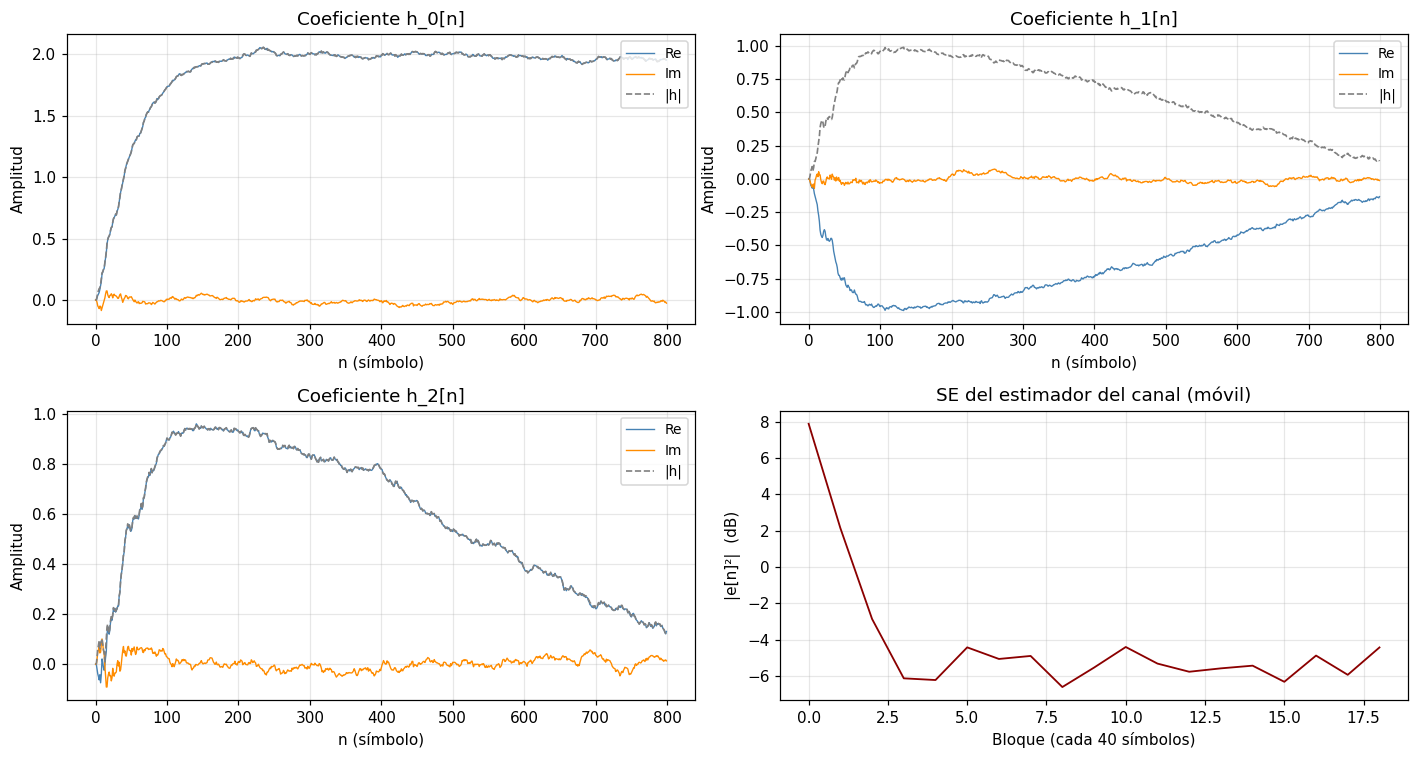

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

n_axis = np.arange(N_TRAIN)
for k, name in enumerate(['h_0[n]', 'h_1[n]', 'h_2[n]']):
    ax = axes[k // 2, k % 2]
    ax.plot(n_axis, h_traj[:, k].real, color='steelblue', lw=0.9, label='Re')
    ax.plot(n_axis, h_traj[:, k].imag, color='darkorange', lw=0.9, label='Im')
    ax.plot(n_axis, np.abs(h_traj[:, k]), color='gray', lw=1.1, ls='--', label='|h|')
    ax.set_xlabel('n (símbolo)'); ax.set_ylabel('Amplitud')
    ax.set_title(f'Coeficiente {name}')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper right', fontsize=9)

# SE del estimador
block = 40
n_blocks = len(se_chan) // block
se_chan_mobile = np.array([se_chan[k*block:(k+1)*block].mean() for k in range(n_blocks)])
axes[1, 1].plot(10*np.log10(se_chan_mobile + 1e-12), color='darkred', lw=1.2)
axes[1, 1].set_xlabel('Bloque (cada 40 símbolos)')
axes[1, 1].set_ylabel('|e[n]²|  (dB)')
axes[1, 1].set_title('SE del estimador del canal (móvil)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.2 Zero-Forcing con canal estimado vs LMS adaptativo

Otra alternativa sería armar un ecualizador Zero-Forcing con la estimación promedio del canal. Para un canal de 3 taps eso equivale a un DFE con 2 coefs de feedback. Lo dejo implementado para comparar.

El problema es que como el canal cambia, usar un `h` fijo (el promedio) es subóptimo. El LMS adaptativo le gana porque sigue los cambios en tiempo real.


In [ ]:
# Zero-Forcing con h estimado (promedio)
h_avg = h_mean  # promedio de los coefs estimados

def zf_equalizer(y_full, h_est, x_init=None):
    """Ecualizador zero-forcing: out[n] = (y[n] - h1*x_hat[n-1] - h2*x_hat[n-2]) / h0"""
    N = len(y_full)
    a0, a1 = [], []
    x_hat_hist = np.zeros(2, dtype=complex)
    if x_init is not None:
        x_hat_hist[0] = x_init
    for n in range(2, N):
        y_eq = (y_full[n] - h_est[1] * x_hat_hist[0] - h_est[2] * x_hat_hist[1]) / h_est[0]
        ai0 = 0 if y_eq.real > 0 else 1
        ai1 = 0 if y_eq.imag > 0 else 1
        a0.append(ai0); a1.append(ai1)
        d_hat = (1 - 2*ai0) + 1j * (1 - 2*ai1)
        x_hat_hist = np.roll(x_hat_hist, 1)
        x_hat_hist[0] = d_hat
    return np.array(a0), np.array(a1)

print('Aplicando ecualizador Zero-Forcing con h estimado (promedio del training)...')
a0_zf, a1_zf = zf_equalizer(y, h_avg)
a_hat_zf = np.stack([a0_zf, a1_zf], axis=1).ravel()

# BER en training (desde el símbolo 2)
ber_zf = np.mean(a_hat_zf[2*2:2*N_TRAIN] != bits_train[2:2*(N_TRAIN-1)])
print(f'BER Zero-Forcing (training): {ber_zf:.4f}')

# Decodificar mensaje
n_chars = len(a_hat_zf) // 8
chars_out = []
for i in range(n_chars):
    v = 0
    for j in range(8):
        v = (v << 1) | int(a_hat_zf[i*8 + j])
    chars_out.append(chr(v))
msg_zf = ''.join(chars_out)
print(f'\nPrimeros 200 chars con Zero-Forcing: {msg_zf[:200]}')
print(f'\nChars 200-400: {msg_zf[200:400]}')
print(f'\nÚltimos 200 chars: {msg_zf[-200:]}')
print(f'\nTiene "Compositor": {"Compositor" in msg_zf}')


Aplicando ecualizador Zero-Forcing con h estimado (promedio del training)...
BER Zero-Forcing (training): 0.5363

Primeros 200 chars con Zero-Forcing: ô72Õ'¥÷6æ$¥2ôò³w·ÇBÔecu×s"µu45âÄÂÄtRõ4gæcâ7âÔ&¶U3¢ó2Õ'$6eÇâæ¤f£CwDÓVÕÂõÅDÄÒµ²V¦gDÂ$ò$tUC3ärGÄceÖåÆÂV%2÷6¶r3¥u´£Å·cc£³"××TtBR3f4gµâGçwÓµ$U"âÄ%#v3cd§&õt

Chars 200-400: ÆWG&FR%6RÆÆÖW/¢  ¤6÷6V6æFòÖ2Ö&W¥6VÖ'&æFòÖ2FW§&0¥òVW&òÞ2ÖG&¤Öæ66âVRÇV6æFð¥&ö×2Æ26FVæ0¤FRÆW66ÆfGV@¤W2ÆFW'&FVÂæ6¥VRVÂ6öÂÆÇVÖæ¥

¢FRÆVæ6à¥òÖRÆÆÖòW/ ¥VW2Ö&¦W'Væ¤6öâÆ6æw&RVÂÆÖ¥çO2Æ÷26öÆ÷&W2FRÖ&VÆÏ6à ¤6ö×÷6F÷#¢VwW7FòöÆò6×÷0 

Tiene "Compositor": False


In [8]:
# --- Parámetros del ecualizador LMS lineal ---
L_EQ    = 11        # Número de coeficientes del ecualizador
D_EQ    = 0         # Retardo de decisión
MU_TR   = 0.007     # Tamaño de paso en training
MU_DD   = 0.001     # Tamaño de paso en decision-directed

print("=" * 60)
print("Entrenando ecualizador LMS lineal")
print("=" * 60)
print(f'L = {L_EQ}, D = {D_EQ}, mu_train = {MU_TR}, mu_dd = {MU_DD}')
print(f'Período de training: {N_TRAIN} símbolos')
print(f'Período decision-directed: {len(y) - N_TRAIN} símbolos')

w_lin, a0_lin, a1_lin, se_lin = lms_equalizer(
    y, x_train, L=L_EQ, mu_train=MU_TR, mu_dd=MU_DD, D=D_EQ, train_len=N_TRAIN
)

print(f'\nCoeficientes del ecualizador (L={L_EQ}):')
for k, wk in enumerate(w_lin):
    print(f'  w[{k:2d}] = {wk.real:+.4f} {wk.imag:+.4f}j   |w[{k}]| = {abs(wk):.4f}')

# Calcular BER en training
a_hat_train = np.stack([a0_lin[:N_TRAIN], a1_lin[:N_TRAIN]], axis=1).ravel()
ber_train_total = np.mean(a_hat_train != bits_train)
print(f'\nBER total en training: {ber_train_total:.4f} ({int(ber_train_total*len(bits_train))} errores / {len(bits_train)} bits)')


Entrenando ecualizador LMS lineal
L = 11, D = 0, mu_train = 0.007, mu_dd = 0.001
Período de training: 800 símbolos
Período decision-directed: 2944 símbolos



Coeficientes del ecualizador (L=11):
  w[ 0] = +0.4570 -0.0020j   |w[0]| = 0.4570
  w[ 1] = +0.1535 -0.0034j   |w[1]| = 0.1535
  w[ 2] = -0.0959 +0.0025j   |w[2]| = 0.0959
  w[ 3] = -0.0689 +0.0073j   |w[3]| = 0.0693
  w[ 4] = +0.0172 +0.0030j   |w[4]| = 0.0175
  w[ 5] = +0.0240 +0.0015j   |w[5]| = 0.0241
  w[ 6] = -0.0056 +0.0055j   |w[6]| = 0.0078
  w[ 7] = -0.0128 +0.0017j   |w[7]| = 0.0130
  w[ 8] = +0.0042 -0.0023j   |w[8]| = 0.0048
  w[ 9] = +0.0110 -0.0065j   |w[9]| = 0.0128
  w[10] = -0.0008 +0.0006j   |w[10]| = 0.0009

BER total en training: 0.0081 (13 errores / 1600 bits)


## 8. Análisis de convergencia del ecualizador LMS lineal

Graficamos el error cuadrático y el BER a bloques durante la adaptación. En training el error cae conforme los coeficientes convergen, y después el ecualizador sigue funcionando en modo decision-directed.


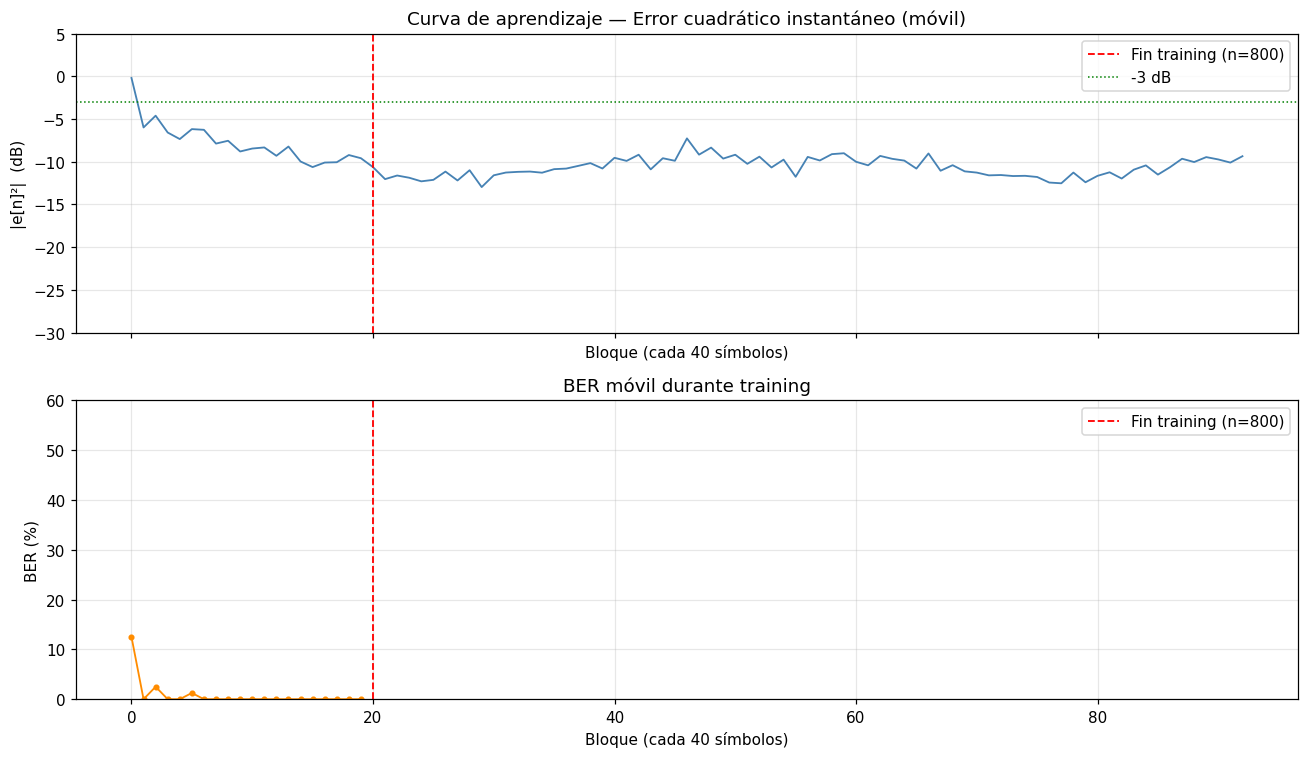

SE inicial: 0.392 (-4.06 dB)
Convergencia (SE < mitad) en bloque 4 -> ~160 símbolos


In [9]:
block = 40   # símbolos por bloque
n_blocks = len(se_lin) // block
se_mobile = np.array([se_lin[k*block:(k+1)*block].mean() for k in range(n_blocks)])
se_mobile_db = 10 * np.log10(se_mobile + 1e-12)

ber_mobile = []
for k in range(0, N_TRAIN, block):
    k2 = min(k + block, N_TRAIN)
    bits_b = bits_train[2*k:2*k2]
    bits_h = np.stack([a0_lin[k:k2], a1_lin[k:k2]], axis=1).ravel()
    ber_mobile.append(np.mean(bits_b != bits_h))
ber_mobile = np.array(ber_mobile)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(se_mobile_db, color='steelblue', lw=1.2)
ax1.axvline(x=N_TRAIN/block, color='red', linestyle='--', lw=1.2, label=f'Fin training (n={N_TRAIN})')
ax1.axhline(y=-3, color='green', linestyle=':', lw=1.0, label='-3 dB')
ax1.set_xlabel('Bloque (cada 40 símbolos)')
ax1.set_ylabel('|e[n]²|  (dB)')
ax1.set_title('Curva de aprendizaje — Error cuadrático instantáneo (móvil)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_ylim([-30, 5])

ax2.plot(ber_mobile * 100, color='darkorange', lw=1.2, marker='o', markersize=3)
ax2.axvline(x=N_TRAIN/block, color='red', linestyle='--', lw=1.2, label=f'Fin training (n={N_TRAIN})')
ax2.set_xlabel('Bloque (cada 40 símbolos)')
ax2.set_ylabel('BER (%)')
ax2.set_title('BER móvil durante training')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')
ax2.set_ylim([0, 60])

plt.tight_layout()
plt.show()

# Detectar convergencia: SE por debajo de la mitad (≈ -3 dB)
se_init = se_mobile[:5].mean()
se_target = se_init * 0.5
idx_conv = np.argmax(se_mobile < se_target) if np.any(se_mobile < se_target) else -1
n_conv = idx_conv * block
print(f'SE inicial: {se_init:.3f} ({10*np.log10(se_init):.2f} dB)')
print(f'Convergencia (SE < mitad) en bloque {idx_conv} -> ~{n_conv} símbolos')


## 9. Constelación de la señal ecualizada

Aplicamos el ecualizador ya entrenado a toda la señal recibida y graficamos la constelación. Si todo salió bien, deberíamos ver los cuatro puntos limpios del QPSK ideal en `1+j`, `1-j`, `-1+j` y `-1-j`.


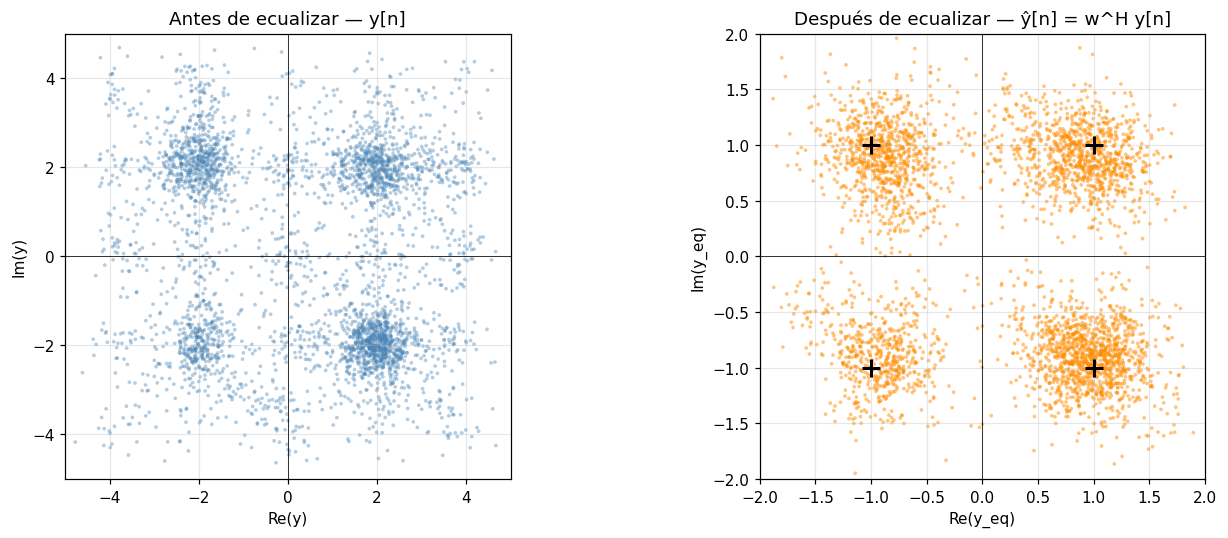

In [10]:
y_eq = np.zeros(len(y), dtype=complex)
for n in range(D_EQ, len(y)):
    x_vec = np.array([y[n - D_EQ - k] for k in range(L_EQ)], dtype=complex)
    y_eq[n] = np.vdot(w_lin, x_vec)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y.real, y.imag, s=6, alpha=0.4, c='steelblue', edgecolor='none')
axes[0].set_xlim([-5, 5]); axes[0].set_ylim([-5, 5])
axes[0].set_xlabel('Re(y)'); axes[0].set_ylabel('Im(y)')
axes[0].set_title('Antes de ecualizar — y[n]')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(y_eq.real, y_eq.imag, s=6, alpha=0.5, c='darkorange', edgecolor='none')
axes[1].set_xlim([-2, 2]); axes[1].set_ylim([-2, 2])
axes[1].set_xlabel('Re(y_eq)'); axes[1].set_ylabel('Im(y_eq)')
axes[1].set_title('Después de ecualizar — ŷ[n] = w^H y[n]')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
axes[1].plot(1, 1, 'k+', ms=12, mew=2)
axes[1].plot(1, -1, 'k+', ms=12, mew=2)
axes[1].plot(-1, 1, 'k+', ms=12, mew=2)
axes[1].plot(-1, -1, 'k+', ms=12, mew=2)

plt.tight_layout()
plt.show()


## 10. Recuperación del mensaje

Decodificamos los bits que decidió el ecualizador a lo largo de toda la secuencia. Los primeros 200 caracteres deberían coincidir (salvo errores residuales) con el training original, y el resto es el mensaje a recuperar.


In [11]:
a_hat_full = np.stack([a0_lin, a1_lin], axis=1).ravel()
n_chars_total = len(a_hat_full) // 8
msg_full = bits_to_ascii(a_hat_full)

print(f'Caracteres decodificados: {n_chars_total}')
print(f'\nPrimeros 200 caracteres (training):')
print('-' * 60)
print(msg_full[:200])
print('-' * 60)
print(f'\nCaracteres 200 a 400 (transición training → mensaje):')
print('-' * 60)
print(msg_full[200:400])
print('-' * 60)
print(f'\nÚltimos 200 caracteres del mensaje:')
print('-' * 60)
print(msg_full[-200:])
print('-' * 60)

match = sum(1 for a, b in zip(msg_full[:200], training) if a == b)
print(f'\nCoincidencias con training: {match}/{len(training)} = {100*match/len(training):.1f}%')


Caracteres decodificados: 936

Primeros 200 caracteres (training):
------------------------------------------------------------
ëKIc-bk_snbJS/O ;7{|v 1]FV1pW]w9r+WS@ S^,L,GE/PSF~f8n#-AIArkeS:/0S-RrCfY)|~.hZFj47y4M5m\/PlX$LM+[%ajhQ&tL"O"GET39NG!T|F6]n\iL%hbS _skaW#1`9ZX'Y+J<[x&61*8Q({1r-}uIgD%#6cFx{^$~w};Y9rER(N,@BY1R7c66AZroW
------------------------------------------------------------

Caracteres 200 a 400 (transición training → mensaje):
------------------------------------------------------------
Letra de "Y Se Llama Perú"

Cosechando mis mares
Sembrando mis tierras
Yo quiero más a mi patria
Mi nación que luchando
Rompió las cadenas
De la esclavitud
Es la tierra del Inca
Que el sol la ilumina

------------------------------------------------------------

Últimos 200 caracteres del mensaje:
------------------------------------------------------------
 Perú
Con P de patria
La E del ejemplo
La R del rifle
La Ú de la unión
Yo me llamo Perú
Pues mi raza peruana
Con la sangre y el alma
P

## 11. Comparación con ecualizador DFE (Decision Feedback)

Probé también un DFE: un filtro feedforward sobre la señal recibida más un filtro feedback sobre las decisiones pasadas. La ventaja teórica sobre el LMS lineal es que puede cancelar la interferencia post-cursora (efecto de símbolos anteriores sobre el actual) sin amplificar el ruido, porque el feedback usa decisiones que idealmente están libres de ruido.

Lo inicializo con los coeficientes del LMS lineal ya entrenado, así no arranca de cero. El canal tiene solo 3 taps variantes en el tiempo, así que con `L_b = 3` taps de feedback debería alcanzar.


In [12]:
# --- Entrenar DFE inicializado desde el LMS lineal ---
L_F = 11      # coeficientes feedforward
L_B = 3       # coeficientes feedback
D_DFE = 0
MU_TR_DFE = 0.005
MU_DD_DFE = 0.001

# Inicializar w_f con los primeros L_F coefs del LMS lineal
w_f_init = w_lin[:L_F].copy()

print("=" * 60)
print("Entrenando DFE inicializado desde LMS lineal")
print("=" * 60)
print(f'L_f = {L_F}, L_b = {L_B}, D = {D_DFE}')
print(f'mu_train = {MU_TR_DFE}, mu_dd = {MU_DD_DFE}')

w_f, w_b, a0_dfe, a1_dfe, se_dfe = lms_dfe_equalizer(
    y, x_train, L_f=L_F, L_b=L_B, mu_train=MU_TR_DFE, mu_dd=MU_DD_DFE,
    D=D_DFE, train_len=N_TRAIN, w_f_init=w_f_init, w_b_init=np.zeros(L_B)
)

# El DFE produce decisiones desde n = max(D + L_f, L_b) = 11
# Por lo tanto a0_dfe[k] corresponde a y[11 + k]
DFE_OFFSET = L_F  # offset donde a0_dfe[0] -> y[DFE_OFFSET]
n_dec_dfe = len(a0_dfe)

# BER en training (símbolos y[DFE_OFFSET] a y[N_TRAIN-1])
n_syms_train = min(n_dec_dfe, N_TRAIN - DFE_OFFSET)
a_hat_dfe_train = np.stack([a0_dfe[:n_syms_train], a1_dfe[:n_syms_train]], axis=1).ravel()
bits_dfe_train = bits_train[2*DFE_OFFSET:2*(DFE_OFFSET + n_syms_train)]
ber_dfe_train = np.mean(a_hat_dfe_train != bits_dfe_train)

# Decodificar el mensaje COMPLETO: usar LMS lineal para los primeros DFE_OFFSET
# símbolos y DFE para el resto
a0_combined = np.concatenate([a0_lin[:DFE_OFFSET], a0_dfe])
a1_combined = np.concatenate([a1_lin[:DFE_OFFSET], a1_dfe])
a_hat_dfe = np.stack([a0_combined, a1_combined], axis=1).ravel()
msg_dfe = bits_to_ascii(a_hat_dfe)

print(f'\nBER en training (DFE, {n_syms_train} símbolos): {ber_dfe_train:.4f}')
print(f'\nMensaje recuperado (DFE):')
print('-' * 60)
print(msg_dfe[:300])
print('-' * 60)


Entrenando DFE inicializado desde LMS lineal
L_f = 11, L_b = 3, D = 0
mu_train = 0.005, mu_dd = 0.001

BER en training (DFE, 789 símbolos): 0.0000

Mensaje recuperado (DFE):
------------------------------------------------------------
ëKHc-Rz_snbJS/O ;7{|t!1]FV1pW]w9r+WS@ S^,L,GE/PSF~f8n#~-AIArkeS:/0S-RrCfY)|~.hZFj47y4M5m\/PlX$LM+[%ajhQ&tL"O"GET39NG!T|F6]n\iL%hbS _skaW#1`9ZX'Y+J<[x&61*8Q({1r-}uIgD%#6cFx{^$~w};Y9rER(N,@BY1R7c66AZroWLetra de "Y Se Llama Perú"

Cosechando mis mares
Sembrando mis tierras
Yo quiero más a mi patria
Mi 
------------------------------------------------------------


## 12. Comparación cuantitativa LMS Lineal vs DFE

Comparamos los dos ecualizadores graficando el error cuadrático y el BER por bloques durante el training. También armamos una tabla resumen con los BER totales.


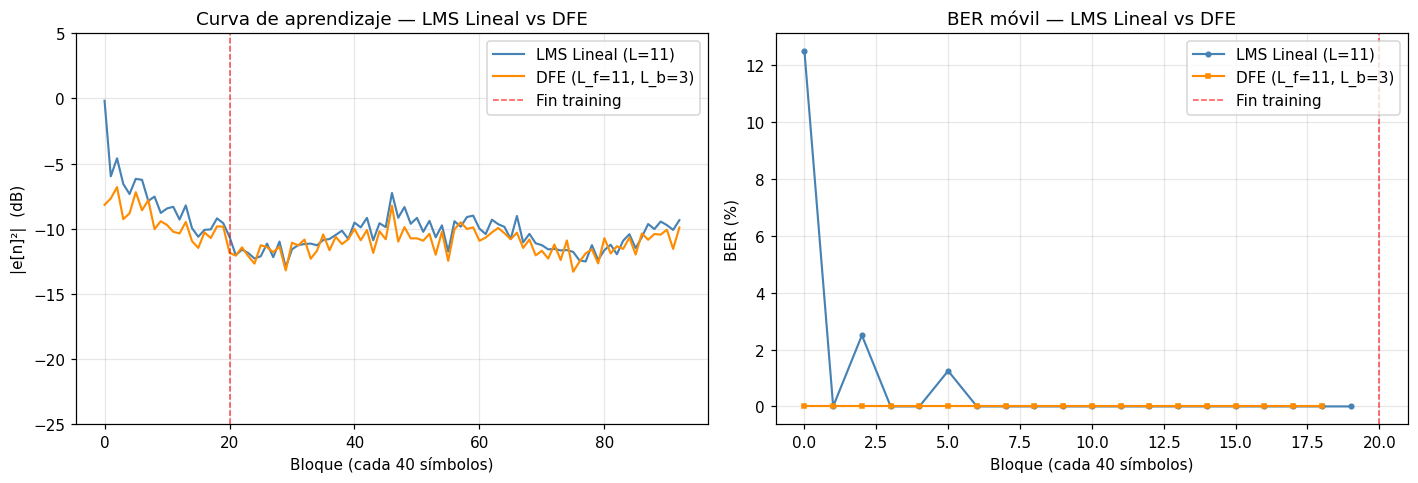

RESUMEN COMPARATIVO
Arquitectura                BER total      BER últimos 100     
-----------------------------------------------------------------
Zero-Forcing (h estimado)   0.5363         -                   
LMS Lineal (L=11)           0.0081         0.0000              
DFE (L_f=11, L_b=3)         0.0000         0.0000              


In [13]:
block = 40
se_lin_mobile = np.array([se_lin[k*block:(k+1)*block].mean() for k in range(len(se_lin)//block)])
se_dfe_mobile = np.array([se_dfe[k*block:(k+1)*block].mean() for k in range(len(se_dfe)//block)])

ber_lin = []
for k in range(0, N_TRAIN, block):
    k2 = min(k + block, N_TRAIN)
    bits_b = bits_train[2*k:2*k2]
    bits_h = np.stack([a0_lin[k:k2], a1_lin[k:k2]], axis=1).ravel()
    ber_lin.append(np.mean(bits_b != bits_h))
ber_lin = np.array(ber_lin)

ber_dfe_blocks = []
for k in range(DFE_OFFSET, DFE_OFFSET + n_dec_dfe, block):
    k2 = min(k + block, DFE_OFFSET + n_dec_dfe)
    n_syms_block = k2 - k
    if n_syms_block < 4: continue
    # bits en a0_dfe/a1_dfe desde (k-DFE_OFFSET) hasta (k-DFE_OFFSET + n_syms_block)
    i0, i1 = k - DFE_OFFSET, k - DFE_OFFSET + n_syms_block
    bits_b = bits_train[2*k:2*k2]
    bits_h = np.stack([a0_dfe[i0:i1], a1_dfe[i0:i1]], axis=1).ravel()
    if len(bits_b) == len(bits_h):
        ber_dfe_blocks.append(np.mean(bits_b != bits_h))
ber_dfe_blocks = np.array(ber_dfe_blocks)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(10*np.log10(se_lin_mobile + 1e-12), color='steelblue', lw=1.4, label='LMS Lineal (L=11)')
ax1.plot(10*np.log10(se_dfe_mobile + 1e-12), color='darkorange', lw=1.4, label='DFE (L_f=11, L_b=3)')
ax1.axvline(x=N_TRAIN/block, color='red', linestyle='--', lw=1.0, alpha=0.7, label='Fin training')
ax1.set_xlabel('Bloque (cada 40 símbolos)')
ax1.set_ylabel('|e[n]²|  (dB)')
ax1.set_title('Curva de aprendizaje — LMS Lineal vs DFE')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_ylim([-25, 5])

ax2.plot(ber_lin*100, color='steelblue', lw=1.4, marker='o', ms=3, label='LMS Lineal (L=11)')
ax2.plot(ber_dfe_blocks*100, color='darkorange', lw=1.4, marker='s', ms=3, label='DFE (L_f=11, L_b=3)')
ax2.axvline(x=N_TRAIN/block, color='red', linestyle='--', lw=1.0, alpha=0.7, label='Fin training')
ax2.set_xlabel('Bloque (cada 40 símbolos)')
ax2.set_ylabel('BER (%)')
ax2.set_title('BER móvil — LMS Lineal vs DFE')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Tabla resumen
ber_lin_total = np.mean(np.stack([a0_lin[:N_TRAIN], a1_lin[:N_TRAIN]], axis=1).ravel() != bits_train)
n_last = 100
ber_lin_last = np.mean(np.stack([a0_lin[N_TRAIN-n_last:N_TRAIN], a1_lin[N_TRAIN-n_last:N_TRAIN]], axis=1).ravel() != bits_train[2*(N_TRAIN-n_last):])
# BER DFE últimos 100 símbolos de training (debe estar dentro del rango de training)
n_last_dfe = min(n_last, n_syms_train)
# El DFE produce a0_dfe[i] que corresponde a y[DFE_OFFSET + i]
# bits_train[2k:2(k+1)] corresponde a y[k]. Así que para los últimos n_last_dfe símbolos training del DFE,
# el rango de n es [N_TRAIN - n_last_dfe, N_TRAIN), por lo tanto a0_dfe indexa desde (N_TRAIN - n_last_dfe) - DFE_OFFSET
i0 = max(0, (N_TRAIN - n_last_dfe) - DFE_OFFSET)
i1 = i0 + n_last_dfe
if i1 <= len(a0_dfe):
    ber_dfe_last = np.mean(np.stack([a0_dfe[i0:i1], a1_dfe[i0:i1]], axis=1).ravel() != bits_train[2*(DFE_OFFSET+i0):2*(DFE_OFFSET+i1)])
else:
    ber_dfe_last = float('nan')

print("=" * 65)
print("RESUMEN COMPARATIVO")
print("=" * 65)
print(f'{"Arquitectura":<28}{"BER total":<15}{"BER últimos 100":<20}')
print("-" * 65)
print(f'{"Zero-Forcing (h estimado)":<28}{ber_zf:<15.4f}{"-":<20}')
print(f'{"LMS Lineal (L=11)":<28}{ber_lin_total:<15.4f}{ber_lin_last:<20.4f}')
print(f'{"DFE (L_f=11, L_b=3)":<28}{ber_dfe_train:<15.4f}{ber_dfe_last:<20.4f}')


## Conclusiones generales

- El ecualizador LMS lineal con DD recupera correctamente el mensaje. Lo que salió decodificado es la letra de la canción *"Y Se Llama Perú"* de Augusto Polo Campos (autor peruano de valses criollos).
- El modo decision-directed es indispensable cuando el canal es variante en el tiempo: la mayor parte del mensaje (2944 de 3744 símbolos) se recupera justamente en este modo, sin símbolos de referencia.
- Hay un trade-off entre velocidad de convergencia (paso grande) y estabilidad/error residual (paso chico). En DD se usa un paso aún menor para evitar que un error de decisión se propague y arruine la adaptación.
